# **Notebook 12 – K-Means Clustering**

## **1. K-Means**

**Understand the Concept**

- K-Means is an Unsupervised Learning algorithm.
- It groups similar data points into clusters.
- K represents the number of clusters.
- Each data point is assigned to the nearest cluster.

**How It Works**

- Select the number of clusters K.
- Choose initial Centroids.
- Assign each data point to the nearest Centroid.
- Update the Centroids.
- Repeat until the clusters become stable.

**Example**

- Group customers into 3 different clusters.
- Customers with similar income and spending behaviour are grouped together.

In [12]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("customer_segmentation.csv")

X = df[["Age","Annual_Income","Spending_Score"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KMeans(n_clusters=3,random_state=42,n_init=10)

df["Cluster"] = model.fit_predict(X_scaled)

print(df[["Age","Annual_Income","Spending_Score","Cluster"]].head())

   Age  Annual_Income  Spending_Score  Cluster
0   56         142165              25        1
1   46         104231              49        1
2   32          25314              46        0
3   60          37623              15        0
4   25         123228              61        2


**Explanation**

- K-Means creates 3 customer clusters.
- StandardScaler puts the features into a similar range.
- Cluster shows the group assigned to each customer.

## **2. Centroids**

**Understand the Concept**

- A Centroid is the center point of a cluster.
- Each cluster has one Centroid.
- K-Means assigns data points based on their distance from the Centroid.
- The Centroid changes as the clusters are updated.

**How It Works**

- K-Means starts with initial Centroids.
- Data points are assigned to the nearest Centroid.
- The Centroid is updated using the mean of the data points in that cluster.

**Formula**

Centroid = Sum of data points / Number of data points

- The mean of all points in a cluster becomes the new Centroid.


## **3. Distance**

**Understand the Concept**

- Distance measures how close or far two data points are.
- K-Means uses distance to find the nearest Centroid.
- Euclidean Distance is commonly used in K-Means.
- Smaller distance means the data point is closer to the Centroid.

**Formula**

Distance = √((x₁ − x₂)² + (y₁ − y₂)²)

- x₁, y₁ → First data point.
- x₂, y₂ → Second data point.



## **4. Cluster Assignment**

**Understand the Concept**

- Cluster Assignment means assigning each data point to a cluster.
- K-Means calculates the distance from each point to every Centroid.
- The point is assigned to the nearest Centroid.
- This process creates different customer groups.

**How It Works**

- Calculate the distance to each Centroid.
- Find the smallest distance.
- Assign the data point to that cluster.

**Example**

- A customer is closest to Cluster 2.
- The customer is assigned to Cluster 2.

## **5. Centroid Update**

**Understand the Concept**

- Centroid Update means finding a new center for each cluster.
- K-Means calculates the mean of all points in each cluster.
- The new mean becomes the updated Centroid.
- This process continues until the Centroids become stable.

**How It Works**

- Find the points assigned to each cluster.
- Calculate the average of their feature values.
- Move the Centroid to the new average position.

**Formula**

New Centroid = Sum of points in cluster / Number of points


## **6. Iterations**

**Understand the Concept**

- Iterations are the repeated steps in K-Means.
- The model repeatedly assigns points and updates Centroids.
- The process continues until the Centroids become stable.
- More iterations help the clusters reach a better position.

**How It Works**

- Assign data points to the nearest Centroid.
- Update the Centroids.
- Repeat these steps until the model converges.

**Example**

- First iteration assigns customers to clusters.
- Later iterations update the clusters until they become stable.

## **7. Choosing K**

**Understand the Concept**

- K represents the number of clusters.
- We need to choose a suitable K value before training K-Means.
- A very small or large K may not give useful groups.
- The Elbow Method can help choose K.

**How It Works**

- Try different K values.
- Compare the clustering performance for each K.
- Select a suitable K based on the results.

**Example**

- Try K values from 2 to 10.
- Choose a suitable K using the Elbow Method.

In [13]:
for k in range(2, 11):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(X_scaled)
    print("K =", k, "Inertia =", model.inertia_)

K = 2 Inertia = 2917.053673127366
K = 3 Inertia = 2223.343831727595
K = 4 Inertia = 1759.4432924254436
K = 5 Inertia = 1550.6534449748076
K = 6 Inertia = 1362.9778943337456
K = 7 Inertia = 1234.2489757166168
K = 8 Inertia = 1118.3814620329194
K = 9 Inertia = 1041.1326510722076
K = 10 Inertia = 965.9108942992455


**Explanation**

- Different K values are tested.
- Inertia shows how close the points are to their Centroids.
- These values can be used with the Elbow Method to choose K.

## **8. Elbow Method**

**Understand the Concept**

- The Elbow Method helps us choose the suitable K value.
- It uses Inertia to measure how close data points are to their Centroids.
- As K increases, Inertia decreases.
- We choose the K value where the decrease starts becoming slower.

**Formula**

Inertia = Σ distance² between each point and its Centroid

**Example**

- Try K values from 2 to 10 and calculate Inertia.
- The point where the graph looks like an elbow can be selected as K.

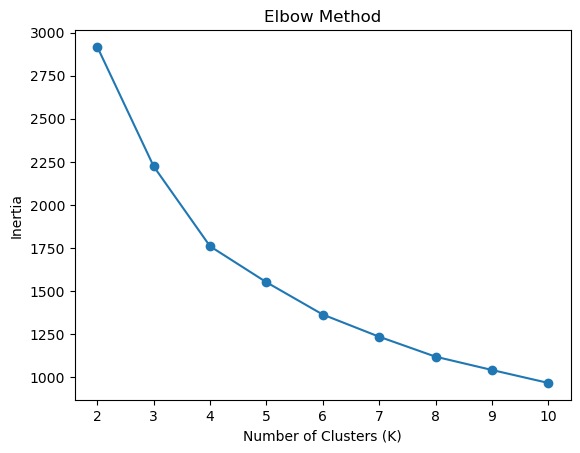

In [14]:
import matplotlib.pyplot as plt
inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## **9. Silhouette Score**

**Understand the Concept**

- Silhouette Score measures how well the data points fit into their clusters.
- It compares the distance within the same cluster and the distance from other clusters.
- The score ranges from -1 to 1.
- A higher score usually means better-separated clusters.

**Formula**

Silhouette Score = (b - a) / max(a, b)

- a → Average distance from points in the same cluster.
- b → Average distance from points in the nearest other cluster.



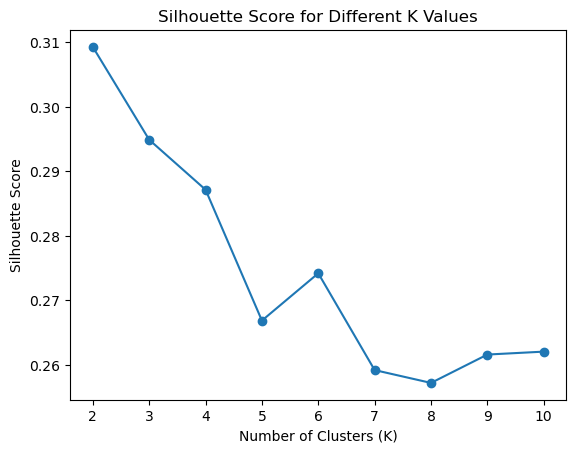

In [15]:
from sklearn.metrics import silhouette_score
scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.show()

## **10. Cluster Interpretation**

**Understand the Concept**

- Cluster Interpretation means understanding each customer group.
- We compare the average values of each cluster.
- This helps us understand customer behaviour.

**Example**

- One cluster may have high income and high spending.
- Another cluster may have low income and low spending.

In [16]:
df["Cluster"] = model.fit_predict(X_scaled) 
cluster_summary = df.groupby("Cluster")[["Age","Annual_Income","Spending_Score"]].mean()
print(cluster_summary)

               Age  Annual_Income  Spending_Score
Cluster                                          
0        27.181818  122449.577922       61.500000
1        51.316176   71873.617647       51.169118
2        49.552000  130009.568000       60.512000
3        49.957627   45445.483051       18.991525
4        52.796178  107946.821656       35.541401
5        24.500000  103707.794118       40.286765
6        46.069307   46012.737624       35.292079
7        27.181818   56654.344156       50.266234
8        27.269461   43986.934132       29.838323
9        38.834437  115979.291391       45.271523


## **11. Visualize the Resulting Clusters**

**Understand the Concept**

- Visualization helps us see the different clusters.
- We can use a scatter plot to compare customers.
- Different clusters are shown separately.



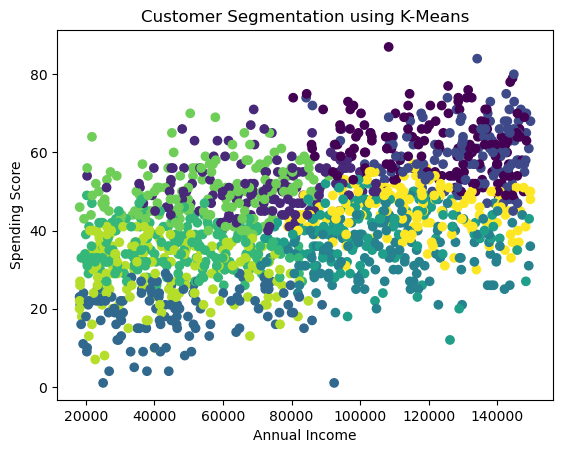

In [17]:
plt.scatter(df["Annual_Income"],df["Spending_Score"],c=df["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()